# 구현 : 시뮬레이션과 완전탐색
- 구현 : 머릿속에 있는 알고리즘을 소스코드로 바꾸는 과정
- 구현 유형 문제 : 풀이를 떠올리는 것은 쉽지만 소스코드로 옮기기 어려운 문제를 지칭
    - 알고리즘은 간단한데 코드가 지나칠만큼 길어지는 문제
    - 문자열을 특정한 기준에 따라서 끊어 처리해야 하는 문제
    - 적절한 라이브러리를 찾아서 사용해야 하는 문제(itertools, collections 등)
- 일반적으로 알고리즘 문제에서는 시뮬레이션 및 완전탐색 문제 등이 있으며, 2차원 공간인 행렬(Matrix) 활용
- 시뮬레이션 : 문제의 설명에 따라 시뮬레이션한 후 결과값을 찾는 문제 (예시 : 좌표이동)
- 완전탐색 : 모든 가능한 경우를 모두 시도하여 정답을 찾아내는 알고리즘 (예시 : 4자리 비밀번호 맞추기)

## 시뮬레이션

### 상하좌우 이동 문제
- 문제설명 <br>
여행가 A는 NxN 크기의 정사각형 공간 위에 서 있습니다. 이 공간은 1x1크기의 정사각형으로 나누어져 있습니다. 가장 왼쪽 위 좌표는 (1,1)이며, 가장 오른쪽 아래 좌표는 (N,N)에 해당합니다. 여행가 A는 상, 하, 좌, 우 방향으로 이동할 수 있으며, 시작 좌표는 항상 (1,1)입니다. 여행가A가 이동할 계획서가 있을 때 최종적으로 도착한 위치는 어디인지 알아보자.
- 입력조건
    - 첫째줄에 공간의 크기를 나타내는 N이 주어집니다. (1≤N≤100)
    - 둘째줄에는 여행할 계획의 내용이 공백을 기준으로 주어집니다. (1≤이동횟수≤100)
        - L(좌), R(우), U(상), D(하) 중 하나의 문자들로 표현됩니다.
    - 입력예시
    ```
    5
    R R R U D D
    ```
- 출력조건 : 여행가A가 최종적으로 도착할 지점의 좌표(x,y)를 공백을 기준으로 출력합니다. (예시: 4 3)

#### 문제해결 아이디어
- 초기좌표(1,1)에서 상하좌우(UDLR)에 따라 좌표를 변경한다.
- 좌표범위가 1보다 작거나 N보다 큰 경우에는 제자리에 있는다.

비슷한 문제<br>
https://school.programmers.co.kr/learn/courses/30/lessons/120861?language=python3

In [ ]:
# 위의 문제 답
def solution(keyinput, board):
    answer = [0,0]
    for k in keyinput:
        if k == 'up':
            answer[1] = min(answer[1]+1, (board[1]//2))
        elif k == 'down':
            answer[1] = max(answer[1]-1, -(board[1]//2))
        elif k == 'left':
            answer[0] = max(answer[0]-1, -(board[0]//2))
        else:
            answer[0] = min(answer[0]+1, (board[0]//2))
    return answer

In [ ]:
# 데이터 입력받기 (수업시간)
n = int(input())
plans = input().split()

# 5 x 5 행렬 # 행렬 만들 필요 없음
#arr = [[0] * n for _ in range(n)]
#print("arr = ",arr)

x = 0
y = 0
# 초기 좌표 설정
#spot = arr[x][y]
#print("spot = ", spot)
# 구현
for i in plans :
    if i == 'U' and y != 0:
        y -= 1
    elif i == 'D' and y != n-1:
        y += 1
    elif i == 'L' and x != 0:
        x -= 1
    elif i == 'R' and x != n-1:
        x += 1

print(f"결과 : ({x},{y})") # 초기좌표 맨 왼쪽 위를 (1,1)로 설정 했으므로 +1

5
R R R U D D 
결과 : (3,2)


In [ ]:
# 방법2
n = int(input())
plans = input().split()

x = 1
y = 1

for i in plans :
    if i =='R' and x < n :
        x += 1
    elif i == 'L' and x > 1:
        x -= 1
    elif i == 'U' and y > 1:
        y -= 1
    elif i == 'D' and y < n:
        y += 1

print(f"결과 : ({x},{y})")

5
R R R U D D
결과 : (4,3)


In [ ]:
# 강사님 방법
n = int(input())
plans = input().split()

# 구현
# x,y 초기좌표
x, y = 1, 1

# 이동계획을 하나씩 확인
for plan in plans :
    # 이동 후 좌표 업데이트
    if plan == 'L':
        x = max(x-1, 1) # 설정된 좌표안에서만 이동하도록
    elif plan == 'R':
        x = min(x+1, n) #5를 못넘어가도록
    elif plan == 'U':
        y = max(y-1, 1)
    elif plan == 'D': # else 로 해도 가능
        y = min(y+1, n)

# 좌표 출력
print(x, y)

5
R R R U D D
4 3


## 완전탐색
- 브루트포스 (Broute Force) : 반복문과 조건문을 사용하여 모든 경우의 값을 찾는 방법
- 백트래킹 (Backtracking) : 답을 찾는 과정에서 해당 경로가 답이 아니라고 판단되는 경우 다른 경로를 탐색하는 방법
- 순열 (Permutaion) : 서로 다른 n개의 원소에서 r개를 중복없이 골라 순서대로 나열하는 방법
- 재귀함수 (Recursion Funtion) : 답을 찾을 때까지 반복적으로 자기자신을 참조하는 함수를 사용하는 방법
- 깊이우선탐색(DFS, Depth-First Search) : 최대한 깊이 내려간 뒤, 더 이상 내려갈 곳이 없을 경우 옆으로 이동하는 방법
- 너비우선탐색(BFS, Breadth-First Search) : 최대한 넓게 이동한 다음, 더이상 이동할 곳이 없을 때 아래로 이동하는 방법

**구현은 비교적 쉽지만 실행시간이 상대적으로 오래 걸리고, 많은 메모리를 사용하므로, 이를 어떻게 구현할지 고민이 필요**

*참고* <br>
완전 탐색은 모든 경우를 탐색하는 것을 말한다.<br>
브루트포스 : 싸그리 몽땅 반복문<br>
백트래킹 : 다 찾지 않고 해당 아닌 경우 돌아감 <br>
ex) 세개를 더해서 10 만들 때 6, 5 두개를 뽑고 이미 10이 넘으면 pass<br>
순열 : 순서대로 나열해 검사<br>
재귀 : 모든 것을 다 검사하는데 1-n 까지 다 하는게 아니라 자기자신을 참조해 검사<br>
깊이 : 깊게 내려가고 옆으로<br>
너비 : 넓게 이동 하고 밑으로


### 블랙잭
[백준](https://www.acmicpc.net/problem/2798)
- 블랙잭 고수 김씨는 새로운 블랙잭 규칙을 가지고 게임을 하려고 합니다. 새로운 블랙잭 버전에서 각 카드에는 양의 정수가 쓰여 있습니다. 그 다음, 딜러는 N장의 카드를 모두 숫자가 보이도록 바닥에 놓습니다. 그런 후에 딜러는 숫자 M을 크게 외칩니다. 이제 플레이어는 제한된 시간 안에 N장의 카드 중에서 3장의 카드를 골라야 하며, 플레이어가 고른 카드의 합은 M을 넘지 않으면서 M과 최대한 가깝게 만들어야 이길 수 있습니다.
N장의 카드에 써져 있는 숫자가 주어졌을 때, M을 넘지 않으면서 M에 최대한 가까운 카드 3장의 합을 구해 출력하세요.
- 입력조건
    - 첫째줄에는 딜러가 바닥에 펼친 카드의 수 N(3≤N≤ 100)과 딜러가 외치는 M(10≤M≤300,000)이 공백을 기준으로 주어집니다.
    - 둘째줄에는 바닥에 펼쳐져 있는 카드에 쓰여있는 수가 공백을 기준으로 주어집니다. 카드의 숫자는 100,000을 넘지 않는 양의 정수입니다.
    - 입력예시
    ```
    5 21
    5 6 7 8 9
    ```
- 출력조건 : M을 넘지 않으면서 M에 최대한 가까운 카드 3장의 합을 출력합니다. (예시 : 21)

#### 문제해결 아이디어
- 펼쳐져 있는 카드를 3장 조합하여 카드의 합을 구한다.
- 합 중 M에 최대한 가까운 합을 출력한다.

In [ ]:
# 나
# 데이터 입력
%%time
n, m = map(int, input().split())
card_list = list(map(int, input().split()))

from itertools import combinations

combs = list(combinations(card_list, 3)) # 겹치지 않게 3개의 조합
result = 0

for comb in combs :
    if sum(comb) <= m :
        result = max (result,sum(comb))

print(result)

5 21
5 6 7 8 9
21
CPU times: user 98 ms, sys: 16.1 ms, total: 114 ms
Wall time: 5.28 s


In [ ]:
# 데이터 입력
n, m = map(int, input().split())
card_list = list(map(int, input().split()))

5 21
5 6 7 8 9


In [ ]:
%%time
# 구현
from itertools import combinations # 세가지 카드만 가져오니까 반복을 허용하진 않음

# 카드 조합 구하기
comb = list(combinations(card_list,3))
# 조합된 카드의 합과 m과의 차이 구하여 딕셔너리 타입으로 저장
sums = {sum(i):sum(i)-21 for i in comb}
# 딕셔너리에서 차이(value)가 0보다 작은 경우에 대해서
# sum(key)를 리스트로 만들고 이중에 가장 큰 sum을 result로
result = max([k for k, v in sums.items() if v <= 0]) #dictionary 타입의 items()는 키값과 value 값을 가져옴
result

CPU times: user 54 µs, sys: 0 ns, total: 54 µs
Wall time: 58.2 µs


21

In [ ]:
# 데이터 입력
n, m = map(int, input().split())
card_list = list(map(int, input().split()))

# 재귀함수 이용한 풀이
%%time
# 결과값을 0으로 초기화
result = 0
# 재귀함수를 이용하여 구하기
def recur(num_card, total, limit=m):
    global result
    # total이 limit보다 크면 함수 종료
    if total > limit:
        return
    # num_card가 3이 되었을때 result를 업데이트 (기존 result보다 크고 limit보다 작은 경우에 대해서만)
    if num_card == 3:
        if total <= limit:
            if total > result:
                result = total
                return
    # 카드를 선택해서 다시 자신을 호출 (카드는 추가가 되고, total은 뽑은 카드의 숫자를 더해서)
    for i in card_list:
        recur(num_card+1, total+i)

recur(0,0,21)
result

CPU times: user 261 µs, sys: 0 ns, total: 261 µs
Wall time: 268 µs


21

# [연습문제] 공바꾸기
- 문제설명 <br>
도현이는 바구니를 총 N개 가지고 있고, 각각의 바구니에는 1번부터 N번까지 번호가 매겨져 있습니다. 바구니에는 공이 1개씩 들어있고, 처음에는 바구니에 적혀있는 번호와 같은 번호가 적힌 공이 들어있습다.
도현이는 앞으로 M번 공을 바꾸려고 합니다. 도현이는 공을 바꿀 바구니 2개를 선택하고, 두 바구니에 들어있는 공을 서로 교환합니다.
공을 어떻게 바꿀지가 주어졌을 때, M번 공을 바꾼 이후에 각 바구니에 어떤 공이 들어있는지 구하는 프로그램을 만들어보자.
- 입력조건
    - 첫째줄에 N (1≤N≤100)과 M (1≤M≤ 100)이 주어진다.
    - 둘째줄부터 M개의 줄에 걸쳐서 공을 교환할 방법이 주어진다. 각 방법은 두 정수 i j로 이루어져 있으며, i번 바구니와 j번 바구니에 들어있는 공을 교환한다는 뜻이다. (1≤i≤j≤ N)
    - 입력예시
    ```
    5 4
    1 2
    3 4
    1 4
    2 2
    ```
- 출력조건 : 1번 바구니부터 N번 바구니에 들어있는 공의 번호를 공백으로 구분해 출력합니다. (예시: 3 1 4 2 5)

In [ ]:
# 데이터 입력
n, m = map(int, input().split())
changes = [tuple(map(int, input().split())) for _ in range(m)]
# 리스트로 받아도 되지만 리스트를 변형할게 아니면 튜플이 더 효율적 (메모리사용)

# 구현
basket = list(range(1,n+1))
for i, j in changes :
    # 바꿔줘야하는 부분 (바로 변경이 가능)
    # 인덱스이기 때문에 -1 씩 해줌
    basket[j-1], basket[i-1] = basket[i-1], basket[j-1]
# 바스켓에 있는것을 다 스트링으로 바꾸고 공백을 기준으로 조인해라
result = ' '.join(map(str, basket))
result

5 4
1 2
3 4
1 4
2 2


'3 1 4 2 5'

## [연습문제] 한수
[백준](https://www.acmicpc.net/problem/1065)
- 문제설명 <br>
어떤 양의 정수 X의 각 자리가 등차수열을 이룬다면, 그 수를 한수라고 합니다. 등차수열은 연속된 두 개의 수의 차이가 일정한 수열입니다. N이 주어졌을 때, 1보다 크거나 같고, N보다 작거나 같은 한수의 개수를 출력하는 프로그램을 작성하세요.
- 입력조건: 첫째 줄에 1,000보다 작거나 같은 자연수 N이 주어집니다. (예시 : 110)
- 출력조건 : 1보다 크거나 같고, N보다 작거나 같은 한수의 개수를 출력합니다. (예시 : 99)



In [ ]:
# 강사님
n = int(input())
# 한수인지 여부파악 하는 함수
def is_hansu(n):
  # 한자리와 두자릿수는 모두 한수
  if(n < 100):
    return True
  # 세자리수 이상일 때
  # 숫자를 문자열로 바꾸고 리스트로 쪼개 그리고 나서 다시 int 형으로 바꿔줌(숫자 바로 쪼개는 것 불가능)
  digits = list(map(int, str(n))) #문자열 자체는 list 형태로 사실 저장되어있음
  differ = digits[1] - digits[0] # 첫번째 차이로 초기값 설정

  for i in range(2, len(digits)) :
      if digits[i] - digits[i-1] != differ :
          return False
  return True

def count_hansu(n):
  count = 0
  for i in range(1,n+1):
      if is_hansu(i) :
        count += 1
  return count

result = count_hansu(n)
result

110


99

# 주요 자료구조 (스택, 큐, 트리)
## 스택(Stack)
- 먼저 들어온 데이터가 나중에 나가는 형식(선입후출)의 자료구조
- 데이터가 삽입되는 순서와 꺼내는 순서가 반대이며, 한 번에 하나의 요소만 추가하거나 제거할 수 있음




In [ ]:
stack =[]

# push (추가)
stack.append(5)
stack.append(2)
stack.append(3)
stack.append(7)

# pop (제거)
print(stack.pop())

# peek (가장 위의 요소 확인)
print(stack[-1])

# 원소값 출력
print(stack)
print(list(reversed(stack)))
print(stack[::-1]) #reverse 같은 의미 /처음부터 끝까지인데 마이너스 단위로?
#[:] 처음부터 끝까지 모든 배열
#[::-1] -1로 뒤에부터 가져오겠다는 의미

7
3
[5, 2, 3]
[3, 2, 5]
[3, 2, 5]


## 큐(Queue)
- 먼저 들어온 데이터가 먼저 나가는 형식(선입선출)의 자료구조
- 한 번에 하나의 요소만 추가하거나 제거할 수 있으며, 먼저 들어온 데이터를 먼저 제거함

In [ ]:
from collections import deque
#import 덱을 한다/ 덱은 양쪽으로 넣고 빼고 할 수 있음
# 덱을 동일하게 쓰지만 팝레프트를 써줘야 큐의 기능을 할 수 있음

queue = deque()

# enqueue (추가)
queue.append(5)
queue.append(2)
queue.append(3)
queue.append(7)

# dequeue (제거)
print(queue.popleft())

# peek (가장 앞에 있는 요소 확인)
print(queue[0])

# 원소값 출력
print(queue)
queue.reverse()
print(queue)
# print(deque(reversed(queue)))

5
2
deque([2, 3, 7])
deque([7, 3, 2])


## 덱(Dequeue)
- 양쪽 끝에서 삽입과 삭제가 가능한 자료 구조
- 한 번에 하나의 요소만 추가하거나 제거할 수 있으며, 앞과 뒤에서 추가, 제거가 가능함

In [ ]:
from collections import deque

deque = deque()

# endeque (추가)
deque.append(5)
deque.appendleft(2)
deque.append(3)
deque.appendleft(7)

# dedeque (제거)
print(deque.pop())
print(deque.popleft())

# peek (가장 앞에 있는 요소 확인)
print(deque[0])

# 원소값 출력
print(deque)
deque.reverse()
print(deque)
# print(deque(reversed(deque)))

3
7
2
deque([2, 5])
deque([5, 2])


## 트리
- 사이클이 없는 양방향 연결 그래프
    - 방향이 없으며, 두 노드사이에는 유일한 경로가 존재
    - 상위에서 하위로 갈 수 있으며, 하위에서 상위로 갈 수 있음
- 비선형 자료구조
    - 원소들 간에 1:n 관계를 가지는 자료구조
    - 원소들 간에 계층 관계를 가지는 계층형 자료구조
    - 상위 원소에서 하위원소로 내려가면서 확장되는 트리(나무)모양의 구조
- 트리의 정의
    - 한개 이상의 노드로 이루어진 유한집합
    - 나머지 노드들은 n(≥0)개의 분리집합 T1, T2, .., TN으로 분리될 수 있음
    - T1, T2, ..., TN은 각각 하나의 트리가 되며(재귀적 정의) 루트의 부트리(subtree)라고 함
- 주요 용어
    - 노드(node) : 트리의 원소        
    - 간선(edge) : 노드를 연결하는 선, 부모노드와 자식 노드를 연결
    - 루트노드(root node) : 트리의 시작 노드
    - 형제노드(sibling node) : 같은 부모 노드의 자식 노드들
    - 조상노드 : 간선을 따라 루트노드까지 이르는 경로에 이르는 모든 노드들
    - 자손노드: 서브트리에 있는 하위 레벨의 노드들
    - 단말노드(leaf node) : 자식노드가 없는 노드
    - 차수(degree)
        - 노드의 차수 : 노드에 연결된 자식 노드의 수
        - 트리의 차수 : 트리에 있는 노드의 차수 중에서 가장 큰 값
        - 단말노드의 차수 = 0
    - 높이(height, label)
        - 노드의 높이 : 루트에서 노드에 이르는 간선의 수, 노드의 레벨
        - 트리의 높이 : 트리에 있는 노드의 높이 중 가장 큰 값, 최대레벨
        - 루트노드의 높이 = 0

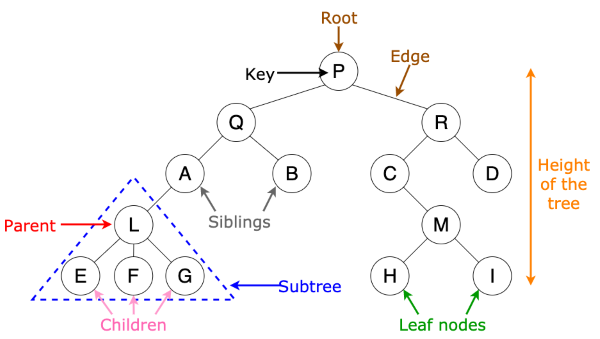


삼각형으로 이을수 없으니 비선형<br>
처음은 Root<br>
node 간의 높이 height<br>
맨 마지막 leaf<br>

다시 보기<br>
위 트리의 높이는 노드의 개수로 4<br>
차수는 반대로 leaf . 가0 root 가 4

### 이진트리
- 모든 노드들이 최대 2개의 서브트리를 갖는 특별한 형태의 트리
    - 각 노드가 자식 노드를 최대한 2개까지만 가질 수 있는 트리
        - 왼쪽 자식 노드(left child node)
        - 오른쪽 자식 노드(right child node)
- 특징
    - 레벨i에서의 노드의 최대개수는
$2^{i}$
    - 높이가 h인 이진 트리가 가질 수 있는 노드의 최소 개수는 (h+1)개가 되며, 최대개수는
($2^{h+1}-1$)개
- 시간복잡도는 높이에 영향을 받음

#### 이진트리 종류
- 포화 이진 트리(Full Binary Tree)
    - 모든 레벨에 노드가 포화상태로 있는 이진트리 (자식노드가 모두 2개)
    - 높이가 h일때, 최대 노드의 개수인 ($2^{h+1}-1$)의 노드를 가진 이진 트리
    - 루트를 1번으로 하여 ($2^{h+1}-1$)까지 정해진 위치에 대한 노드 번호를 가짐
- 완전 이진 트리(Complete Binary Tree)
    - 높이가 h이고 노드 수가 n개일때, 포화이진트리의 노드번호 1번부터 n번까지 빈자리가 없는 이진트리
    - 높이 h-1까지 포화이진트리의 형태
    - 노드의 개수는 $2^{h} \le n \le 2^{h+1} -1$
- 편향 이진 트리(Skewed Binary Tree)
    - 높이 h에 대한 최소 노드의 개수를 가지면서 한쪽 방향의 자식 노드만 가지는 이진트리
        - 왼쪽 편향 이진 트리
        - 오른쪽 편향 이진 트리

완전 이진 트리<br>
-> 마지막 레벨의 노드가 왼쪽부터 채워져있어야함(다안채워져있더라도)

## 순회(Traversal)
- 순회란 트리의 각 노드를 중복되지않게 전부 방문하는 것을 말하며, 트리는 비선형 구조이기 때문에 선형구조에서와 같이 선후 연결 관계를 알 수 없음
- 기본적인 순회 방법
    - 전위 순회(preorder traversal) : VLR <br>
    자손노드보다 현재노드를 먼저 방문
    - 중위 순회(inorder traversal) : LVR <br>
    왼쪽자손, 현재, 오른쪽 자손 노드 순으로 방문
    - 후위 순회(postoder traversal) : LRV <br>
    현재노드보다 자손노드를 먼저 방문

                   V = vertex(부모)

        L                         R


VLR : 부모부터 보고 자식 순서대로 <br>
LVR : 순서대로 왼쪽 나 오른쪽 <br>
LRV : 자식들먼저 LR 그다음 내가 V <br>
V의 위치로 전위 중위 후위를 볼 수 있음 <br>
V가 앞에 전위 중간에 중위 뒤에 후위

In [ ]:
# 전위 순회 알고리즘
def preorder_traverse(Tree T):
    if T:
        visit(T) # 자기 보고
        preorder_traverse(T.left) # left 보고
        preorder_traverse(T.right) # right 보고

In [ ]:
# 중위 순회 알고리즘
def inorder_traverse(Tree T):
    if T:
        inorder_traverse(T.left)
        visit(T)
        inorder_traverse(T.right)

In [ ]:
# 후위 순회 알고리즘
def postorder_traverse(Tree T):
    if T:
        postorder_traverse(T.left)
        postorder_traverse(T.right)
        visit(T)

                          이진트리
                              1
               
               2                             3

      4                 5            6


  전위 : 1 2 4 5 3 6<br>
  중위 : 4 2 5 1 6 3<br>
  후위 : 4 5 2 6 3 1

[연습문제] 이진트리의 순회
1. 전위순회의 노드 방문순서
2. 중위순회의 노드 방문순서
3. 후위순회의 노드 방문순서

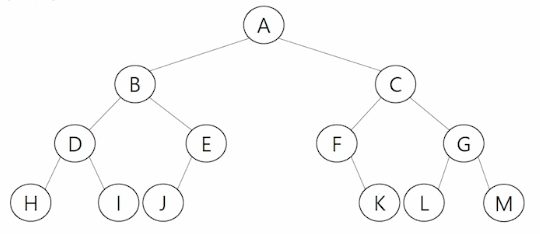

나 <br>
전위 : A B D H I E J C F K G L M<br>
중위 : H D I B J E A F K C L G M<br>
후위 : H I D J E B K F L M G C A<br>

강사님<br>
전위 : A B D H I E J C F K G L M<br>
중위 : H D I B J E A F K C L G M<br>
후위 : H I D J E B K F L M G C A<br>

** 무조건 서브트리가 다 끝나야함! A의 위치로 보면 전위는 맨앞, 중위 중간, 후위 뒤에 나오는 것을 볼 수 있다.

### 배열을 이용한 이진 트리의 표현
- 이진 트리에 각 노드 번호를 배열의 순서에 따라 부여
- 루트의 번호를 1로 함
- 레벨n에 있는 노드에 대하여 왼쪽부터 오른쪽으로 $2^{n}$부터 $2^{n+1} - 1$까지 번호를 차례로 부여
- 노드 번호의 성질
    - 노드번호가 i인 노드의 부모 노드은 번호 : i//2
    - 노드번호가 i인 노드의 왼쪽 자식 노드 번호 : 2*i
    - 노드번호가 i인 노드의 오른쪽 자식 노드 번호 : 2*i + 1
    - 레벨n의 노드번호 시작 번호 : $2^{n}$
- 노드번호를 배열의 인덱스로 사용
    - 높이가 h인 이진트리를 위한 배열의 크기 : $2^{h+1}-1$ ➡ 높이가 클 경우, 배열의 크기 기하급수적으로 커짐
    - 두개의 배열을 이용하는 방법
        - 부모번호를 인덱스로, 자식번호를 저장

        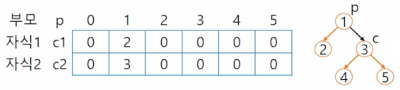
        - 자식번호를 인덱스로, 부모번호를 저장

        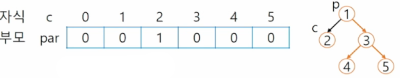
    - 링크드 표현법
        - Left, Vertex, Right에 대한 주소값을 가지고 연결하여 표현하는 방법    
        ➡ 각 left와 right의 값을 주소로 하기 때문에 알고리즘문제풀이에서는 잘 사용하지 않음

        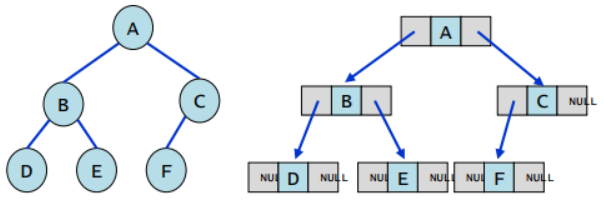

## 이진트리의 전위순회 순서
- 문제설명 <br>
이진트리는 한 부모에 대하여 최대 2개의 자식노드를 갖는 트리입니다. 정점의 개수 N개가 주어지고 정점에 대하여 N-1개의 간선이 있는 이진트리가 주어졌을 때 이를 전위순회하는 방문하는 정점의 순서를 나열해보자.
- 입력조건
    - 첫째줄에는 트리의 정점의 총 수 N(1≤N≤100)개가 주어집니다.
    - 둘째줄에는 트리를 이루는 간선에 대해 N-1개에 대하여 공백을 기준으로 나열됩니다. 1과 2는 정점1과 2를 잇는 간선을 의미하며 1이 부모, 2가 자식을 의미합니다. 간선은 부모 정점 번호가 작은 것부터 나열되고, 부모 정점이 동일하다면 자식 정점 번호가 작은것부터 나열됩니다.
    - 입력예시
    ```
    13
    1 2 1 3 2 4 3 5 3 6 4 7 5 8 5 9 6 10 6 11 7 12 11 13
    ```
- 출력조건 : 입력된 이진트리에 대하여 전위 순회한 결과를 공백을 기준으로 출력합니다. (예시: 1 2 4 7 12 3 5 8 9 6 10 11 13)

In [ ]:
# 데이터 입력
n = int(input())
array = list(map(int, input().split()))

# 자식(left, right)를 리스트로 갖는 이진트리 구현
left = [0] * (n+1) # 전체의 개수만큼 만들어주는 것
right = [0] * (n+1)

for i in range(0, len(array), 2) : # 2로 나눠서 받아올 수 있고
  parent, child = array[i] , array[i+1] # for  두개씩 ㅅ끊어가져옴
  if left[parent] == 0 : #left 자식이 없다
    left[parent] = child
  else :
    right[parent] = child

def preorder(node) :
  if node == 0:
    return
  else :
    print(node, end=' ') # 내가 방문한거 먼저
    preorder(left[node])
    preorder(right[node])


# 전위 순회(VLR)
preorder(1) #1부터 시작

13
1 2 1 3 2 4 3 5 3 6 4 7 5 8 5 9 6 10 6 11 7 12 11 13
1 2 4 7 12 3 5 8 9 6 10 11 13 

## 트리의 부모 찾기
[백준](https://www.acmicpc.net/problem/11725)
- 문제설명 <br>
루트 없는 트리가 주어집니다. 이때, 트리의 루트를 1이라고 정했을 때, 각 노드의 부모를 구하는 프로그램을 작성하시오.
- 입력조건
    - 첫째 줄에 노드의 개수 N (2 ≤ N ≤ 100,000)이 주어집니다.
    - 둘째 줄부터 N-1개의 줄에 트리 상에서 연결된 두 정점이 주어집니다.
    - 입력예시
    ```
    7
    1 6
    6 3
    3 5
    4 1
    2 4
    4 7
    ```
- 출력조건 : 첫째줄부터 N-1개의 줄에 각 노드의 부모 노드 번호를 2번 노드부터 순서대로 출력한다.
    - 출력예시
    ```
    4
    6
    1
    3
    1
    4
    ```

In [ ]:
# 데이터 입력
n = int(input())
links = [tuple(map(int, input().split())) for _ in range(n-1)]
# 부모를 리스트로 갖는 트리 구현
# 자식을 인덱스로 해서 부모 값을 갖는 애

#배열 만들어줌
parents = [0]*(n+1) #노드번호대로 만들어주기 위해 +1 원래 인덱스는 0부터 시작
#입력해줌
# 튜플로 받아서 쌍쌍이 가져오는 링크스 에서
for i,j in links:
  # 둘중 하나라도 1이라면 나머지가 자식이고 그거에 대한 인덱스로 부모가 1이라는 것을 알 수 있다.
  # 1번은 루트로 항상 부모, 그래서 둘중 하나라도 1이있다면 그것은 1의 자식
  if i == 1 : # 내가 부모니까 j가 자식
    parents[j] = 1
  elif j == 1 : # j가 부모 i가 자식
    parents[i] =1
  else :
    # 부모는 한명밖에 가질 수 없기 때문에 둘중 하나가 부모가 있다면 그것은 부모가 됨
    if parents[i] != 0 :#2번에 부모가 있으니 자식 밖에 있을 수밖에 없음
       parents[j] = i #다른애의 부모가 i다 라고 하는거
    elif parents[j] != 0 :#j에 대한 부모는 정해져 있음 j가 이미 부모가 있다는 뜻 그니까 나는 i의 자식
       parents[i] = j

# 트리의 부모노드 출력(2부터)
result = "\n".join(map(str,parents[2:]))
print(result)

7
1 6
6 3
3 5
4 1
2 4
4 7
4
6
1
3
1
4
[0, 0, 4, 6, 1, 3, 1, 4]


####[연습문제] 트리 순회
- 문제설명 <br>
이진 트리를 입력받아 전위 순회(preorder traversal), 중위 순회(inorder traversal), 후위 순회(postorder traversal)한 결과를 출력하는 프로그램을 작성하세요.
- 입력조건
    - 첫째 줄에는 이진 트리의 노드의 개수 N(1≤N≤26)이 주어집니다.
    - 둘째 줄부터 N개의 줄에 걸쳐 각 노드와 그의 왼쪽 자식 노드, 오른쪽 자식 노드가 주어집니다. 노드의 이름은 A부터 차례대로 알파벳 대문자로 매겨지며, 항상 A가 루트 노드가 된다. 자식 노드가 없는 경우에는 '.'으로 표현합니다.
    - 입력예시
    ```
    7
    A B C
    B D .
    C E F
    E . .
    F . G
    D . .
    G . .
    ```
- 출력조건 : 첫째 줄에 전위 순회, 둘째 줄에 중위 순회, 셋째 줄에 후위 순회한 결과를 출력합니다. 각 줄에 N개의 알파벳을 공백 없이 출력하면 됩니다.
    - 출력예시
    ```
    ABDCEFG
    DBAECFG
    DBEGFCA
    ```

In [ ]:
# 데이터입력
n = int(input())
links = [tuple(input().split()) for _ in range(n)]

# 이진트리 구현
# 노드의 값이 문자이기 때문에 부모노드를 key, 자식을 value로 하는 딕셔너리 형태로 만듬
tree = {}
for n, i, j in links:
    tree[n] = (i, j)

## node가 '.'이라면 출력하지 출력하지 않도록 ''을 리턴
## 그렇지 않다면 순회하여 리턴

# 전위 순회(VLR)
def preorder(tree, node):
    if node == '.':
        return ''
    else:
        return node + preorder(tree, tree[node][0]) + preorder(tree, tree[node][1]) # V+L+R

# 중위 순회(LVR)
def inorder(tree, node):
    if node == '.':
        return ''
    else:
        return inorder(tree, tree[node][0]) + node + inorder(tree, tree[node][1])   # L+V+R

# 후위 순회(LRV)
def postorder(tree, node):
    if node == '.':
        return ''
    else:
        return postorder(tree, tree[node][0]) + postorder(tree, tree[node][1]) + node   # L+R+V

# 각 순회 결과 출력
print(preorder(tree, 'A'))
print(inorder(tree, 'A'))
print(postorder(tree, 'A'))